In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pylidlight
import numpy as np

# ERA5

Здесь описаны примеры работы с данными реанализа ERA5. Данные храняться в базе с часовым интервалом.


Place(id=1, latitude=54.95, longitude=82.94, name='Novosibirsk')
	Count: 122712, 
	from
		[Date(id=491545, place_id=1, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[Date(id=570408, place_id=1, timestamp=1672527600, date=datetime.datetime(2022, 12, 31, 23, 0, tzinfo=datetime.timezone.utc))]


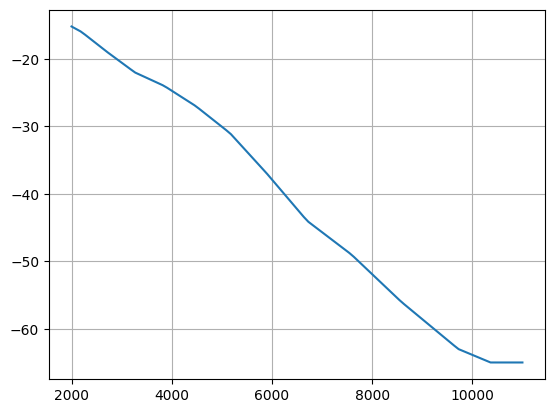


Place(id=2, latitude=55.32, longitude=78.35, name='Barabinks')
	Count: 122712, 
	from
		[Date(id=697, place_id=2, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[Date(id=123408, place_id=2, timestamp=1672527600, date=datetime.datetime(2022, 12, 31, 23, 0, tzinfo=datetime.timezone.utc))]


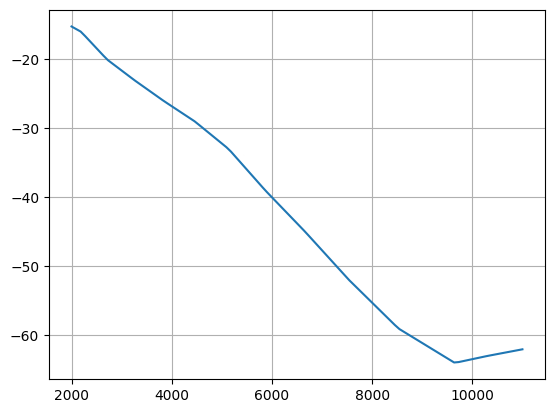


Place(id=3, latitude=56.17, longitude=92.6, name='Emelyanovo')
	Count: 122712, 
	from
		[Date(id=123409, place_id=3, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[Date(id=246120, place_id=3, timestamp=1672527600, date=datetime.datetime(2022, 12, 31, 23, 0, tzinfo=datetime.timezone.utc))]


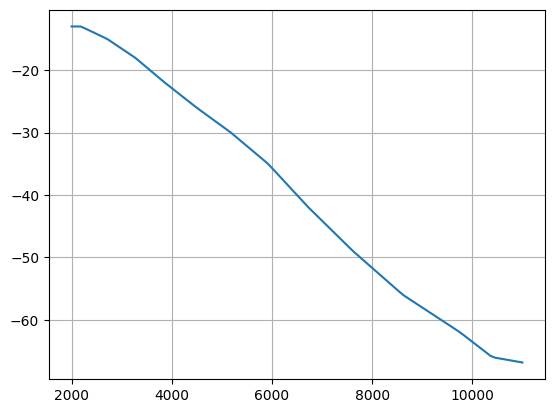


Place(id=4, latitude=56.42, longitude=84.79, name='Lidar(Tomsk)')
	Count: 123769, 
	from
		[Date(id=614257, place_id=4, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[Date(id=738025, place_id=4, timestamp=1677628800, date=datetime.datetime(2023, 3, 1, 0, 0, tzinfo=datetime.timezone.utc))]


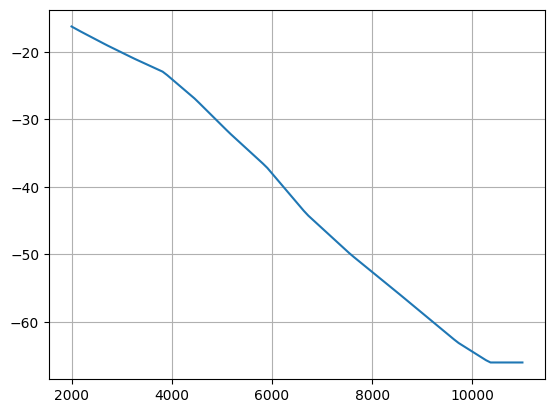


Place(id=5, latitude=58.3, longitude=82.94, name='Kolpashevo')
	Count: 122712, 
	from
		[Date(id=368833, place_id=5, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[Date(id=447696, place_id=5, timestamp=1672527600, date=datetime.datetime(2022, 12, 31, 23, 0, tzinfo=datetime.timezone.utc))]


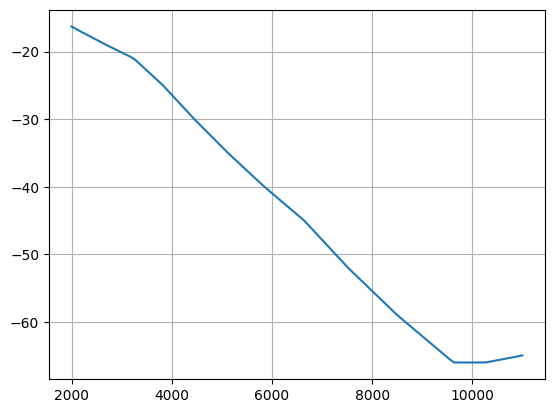


Place(id=6, latitude=58.44, longitude=92.14, name='Eniseysk')
	Count: 122712, 
	from
		[Date(id=246121, place_id=6, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[Date(id=324984, place_id=6, timestamp=1672527600, date=datetime.datetime(2022, 12, 31, 23, 0, tzinfo=datetime.timezone.utc))]


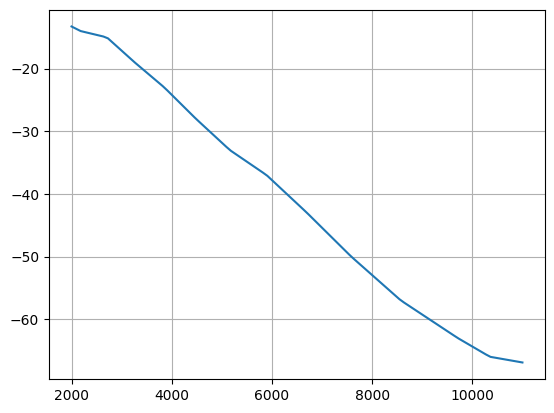

closed


In [2]:
with pylidlight.DB("data-challenge.db") as db:
    places = db.get_places()
    for p in places:
        print()
        print(p)

        data = db.get_era5_data(p)
        print(f"\tCount: {len(data)}, \n\tfrom\n\t\t[{data[0]}]\n\tto\n\t\t[{data[-1]}]")

        N = 100

        # Получить все как есть
        altitudes, measurements = db.get_era5_measurements(data[N], pylidlight.Measure.TEMPERATURE)
        # Получить все ниже 6000 м как есть
        altitudes, measurements = db.get_era5_measurements(data[N], pylidlight.Measure.TEMPERATURE, altitude=6000)
        # Получить на сетке высот (будет интерполировано на эту сетку)
        altitudes, measurements = db.get_era5_measurements(
            data[N], pylidlight.Measure.TEMPERATURE,
            altitude=np.linspace(2000, 11000, 100))
        plt.figure()
        plt.plot(altitudes, measurements)
        plt.grid()
        plt.show()


Можно загружать данные в конкретный момент времени, используя линейную интерполяцию.

In [7]:
with pylidlight.DB("data-challenge.db") as db:
    places = db.get_places()
    for p in places:
        print()
        print(p)

        # Загружаем в конкретный момент времени (timestamp). 
        # Если загрузить не получится, то вылетит ошибка
        altitudes, measurements = db.get_era5_measurements_approx(
            p, pylidlight.Measure.TEMPERATURE, 1430768000,
            altitudes=np.linspace(3000, 12000, 10)
        )

        print("Alts: ", altitudes)
        print("Meas: ", measurements)


Place(id=1, latitude=54.95, longitude=82.94, name='Novosibirsk')
Alts:  [ 3000.  4000.  5000.  6000.  7000.  8000.  9000. 10000. 11000. 12000.]
Meas:  [np.float64(-6.716521739130435), np.float64(-13.450980392156863), np.float64(-19.851063829787233), np.float64(-27.37795275590551), np.float64(-35.70446320868516), np.float64(-44.433925049309664), np.float64(-52.24762726488352), np.float64(-58.28731665228646), np.float64(-59.91488452928007), np.float64(-55.46438525095573)]

Place(id=2, latitude=55.32, longitude=78.35, name='Barabinks')
Alts:  [ 3000.  4000.  5000.  6000.  7000.  8000.  9000. 10000. 11000. 12000.]
Meas:  [np.float64(-4.613793103448276), np.float64(-11.299837925445704), np.float64(-18.980169971671387), np.float64(-27.1496062992126), np.float64(-35.459589867310015), np.float64(-43.16454456415279), np.float64(-50.02056555269923), np.float64(-56.8757497857755), np.float64(-59.28552097428958), np.float64(-55.969339622641506)]

Place(id=3, latitude=56.17, longitude=92.6, name='

# Аэрология

В базе присутствую данные реальных наблюдений в городах рядом. Для предсказания напрямую их использовать нельзя, так как нет данных для всего диапазона дат, в частности для 2024 года. Могут пригодиться для корректировки/валидации ERA5.


Place(id=1, latitude=54.95, longitude=82.94, name='Novosibirsk')
	Count: 10195, 
	from
		[AeroData(id=40606, place_id=1, elevation=143.0, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[AeroData(id=50616, place_id=1, elevation=143.0, timestamp=1681300800, date=datetime.datetime(2023, 4, 12, 12, 0, tzinfo=datetime.timezone.utc))]


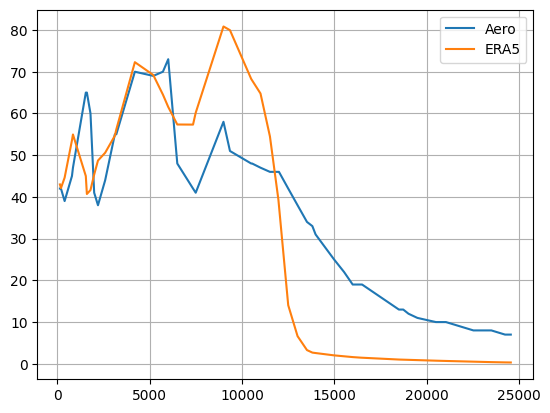


Place(id=2, latitude=55.32, longitude=78.35, name='Barabinks')
	Count: 10223, 
	from
		[AeroData(id=166, place_id=2, elevation=120.0, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[AeroData(id=10223, place_id=2, elevation=120.0, timestamp=1681300800, date=datetime.datetime(2023, 4, 12, 12, 0, tzinfo=datetime.timezone.utc))]


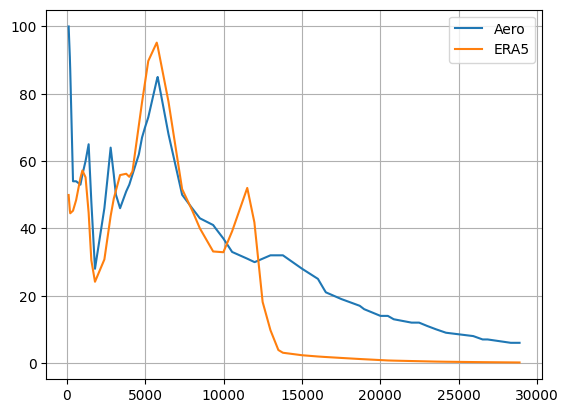


Place(id=3, latitude=56.17, longitude=92.6, name='Emelyanovo')
	Count: 10148, 
	from
		[AeroData(id=10405, place_id=3, elevation=206.0, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[AeroData(id=20371, place_id=3, elevation=206.0, timestamp=1681300800, date=datetime.datetime(2023, 4, 12, 12, 0, tzinfo=datetime.timezone.utc))]


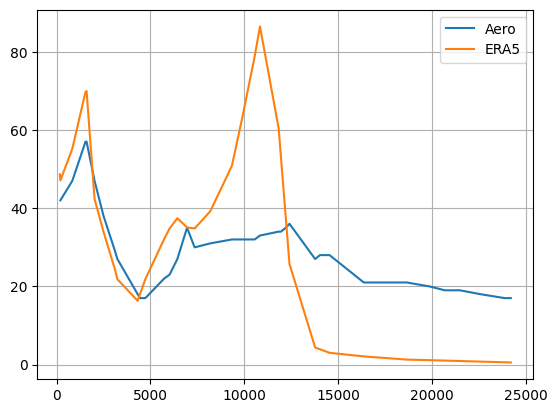


Place(id=4, latitude=56.42, longitude=84.79, name='Lidar(Tomsk)')
	Count: 0, 
	from
		[-1]
	to
		[-1]

Place(id=5, latitude=58.3, longitude=82.94, name='Kolpashevo')
	Count: 10018, 
	from
		[AeroData(id=30574, place_id=5, elevation=75.0, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[AeroData(id=40421, place_id=5, elevation=75.0, timestamp=1681300800, date=datetime.datetime(2023, 4, 12, 12, 0, tzinfo=datetime.timezone.utc))]


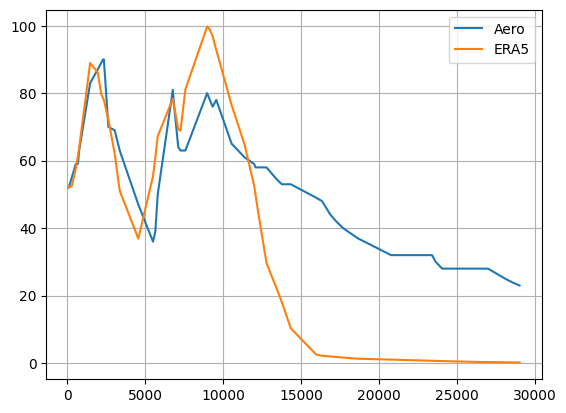


Place(id=6, latitude=58.44, longitude=92.14, name='Eniseysk')
	Count: 10032, 
	from
		[AeroData(id=20556, place_id=6, elevation=79.0, timestamp=1230768000, date=datetime.datetime(2009, 1, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[AeroData(id=30403, place_id=6, elevation=79.0, timestamp=1681300800, date=datetime.datetime(2023, 4, 12, 12, 0, tzinfo=datetime.timezone.utc))]


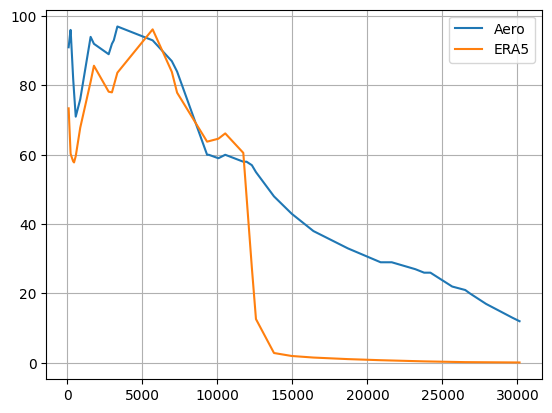

closed


In [8]:
with pylidlight.DB("data-challenge.db") as db:
    places = db.get_places()
    for p in places:
        print()
        print(p)

        data = db.get_aero_data(p)
        print(f"\tCount: {len(data)}, \n\tfrom\n\t\t[{data[0] if len(data) else -1}]\n\tto\n\t\t[{data[-1] if len(data) else -1}]")
        if not data: continue

        N = 500

        m = pylidlight.Measure.REL_HUMIDITY
        # Получить все как есть
        altitudes, measurements = db.get_aero_measurements(data[N], m)

        _, era5 = db.get_era5_measurements_approx(p, m, data[N].timestamp, altitudes=altitudes)
        # # Получить все ниже 6000 м как есть
        # altitudes, measurements = db.get_aero_measurements(data[N], pylidlight.Measure.TEMPERATURE, altitude=6000)
        # # Получить на сетке высот (будет интерполировано на эту сетку)
        # altitudes, measurements = db.get_aero_measurements(
        #     data[N], pylidlight.Measure.TEMPERATURE,
        #     altitude=np.linspace(2000, 11000, 100))
        plt.figure()
        plt.plot(altitudes, measurements, label="Aero")
        plt.plot(altitudes, era5, label="ERA5")
        plt.legend()
        plt.grid()
        plt.show()


# Солнце

Есть данные положения Солнца в Томске.

In [12]:
with pylidlight.DB("data-challenge.db") as db:
    place = db.get_place("Lidar(Tomsk)") # Можно загрузить конкретное место
    print(p)
    # Загружаем все данные как есть
    data = db.get_sun_measurements(p)
    print(f"\tCount: {len(data)}, \n\tfrom\n\t\t[{data[0] if len(data) else -1}]\n\tto\n\t\t[{data[-1] if len(data) else -1}]")

Place(id=4, latitude=56.42, longitude=84.79, name='Lidar(Tomsk)')
	Count: 7493759, 
	from
		[SunData(id=1, place_id=4, timestamp=1259625600, azimuth=-36.49, zenith=141.5, date=datetime.datetime(2009, 12, 1, 0, 0, tzinfo=datetime.timezone.utc))]
	to
		[SunData(id=7483679, place_id=4, timestamp=1709251141, azimuth=336.5, zenith=129.8, date=datetime.datetime(2024, 2, 29, 23, 59, 1, tzinfo=datetime.timezone.utc))]
closed


Можно загрузить интерполированные значение для положения Солнца в любой момент времени

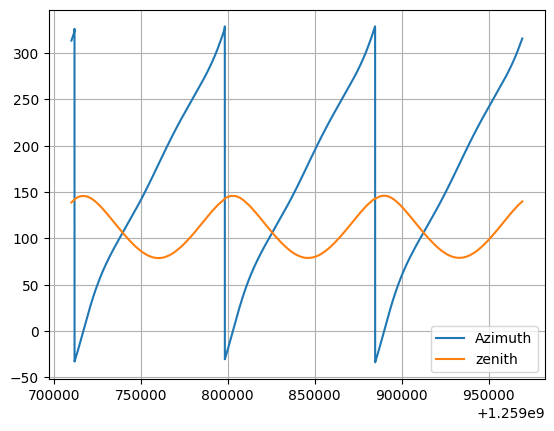

closed


In [13]:
with pylidlight.DB("data-challenge.db") as db:
    place = db.get_place("Lidar(Tomsk)")

    azimuth = []
    zenith = []
    start = 1259625600 + 3600 * 23.5
    timestamps = np.linspace(start, start+3600*24*3, 10000)
    for t in timestamps:
        data = db.get_sun_measurements_approx(place, t)
        azimuth.append(data.azimuth)
        zenith.append(data.zenith)

    plt.plot(timestamps, azimuth, label="Azimuth")
    plt.plot(timestamps, zenith, label="zenith")
    plt.legend()
    plt.grid()
    plt.show()


In [23]:
with pylidlight.DB("data.db") as db:
    place = db.get_place("Lidar(Tomsk)")
    print(place)    
    #df = db.get_lidar_dataframe(place, category=pylidlight.Category.LOW_SIGNAL)
    #df = db.get_lidar_dataframe(place, category=pylidlight.Category.HIGH_LEVEL_CLOUD)
    df = db.get_lidar_dataframe(place, category=None)
    df.head()

Place(id=4, latitude=56.42, longitude=84.79, name='Lidar(Tomsk)')
closed


In [24]:
df

,date_started_at,date_finished_at,timestamp_started_at,timestamp_finished_at,altitude,channel,snr,m01,m02,m03,...,m07,m08,m09,m10,m11,m12,m13,m14,m15,m16
0,2009-12-14 17:43:27+06:00,2009-12-14 18:00:09+06:00,1260791007,1260792009,9000.0,Channel.MAIN,7.00,1.0,0.01,-2.52,...,-0.07,0.02,2.52,-2.12,-0.97,3.42,1.16,-1.25,0.52,1.47
1,2009-12-14 17:43:27+06:00,2009-12-14 18:00:09+06:00,1260791007,1260792009,9150.0,Channel.MAIN,3.00,1.0,0.03,-0.09,...,-0.05,0.06,0.09,0.20,-0.54,0.10,0.36,-0.25,0.39,-0.29
2,2009-12-14 17:43:27+06:00,2009-12-14 18:00:09+06:00,1260791007,1260792009,9300.0,Channel.MAIN,31.00,1.0,-0.07,0.19,...,-0.05,0.02,-0.19,0.22,-1.21,-0.22,-0.10,0.17,-0.18,-0.94
3,2009-12-14 17:43:27+06:00,2009-12-14 18:00:09+06:00,1260791007,1260792009,9450.0,Channel.MAIN,89.67,1.0,-0.12,0.17,...,-0.28,-0.15,-0.17,-0.27,-1.22,-1.01,0.11,-0.39,-0.08,-1.20
4,2009-12-14 17:43:27+06:00,2009-12-14 18:00:09+06:00,1260791007,1260792009,9600.0,Channel.MAIN,109.67,1.0,-0.07,0.22,...,-0.13,-0.21,-0.22,0.08,-0.84,-0.53,-0.20,0.01,-0.24,-1.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45940,2024-11-06 15:00:45+07:00,2024-11-06 15:17:25+07:00,1730880045,1730881045,5850.0,Channel.PARALLEL,23.49,1.0,0.01,0.02,...,-0.04,-0.04,-0.02,0.07,-1.00,0.04,0.02,-0.08,0.17,-1.01
45941,2024-11-06 15:00:45+07:00,2024-11-06 15:17:25+07:00,1730880045,1730881045,6000.0,Channel.PARALLEL,31.13,1.0,0.00,0.05,...,-0.10,-0.03,-0.05,0.04,-1.05,0.13,0.00,-0.03,0.09,-0.99
45942,2024-11-06 15:00:45+07:00,2024-11-06 15:17:25+07:00,1730880045,1730881045,6150.0,Channel.PARALLEL,3.93,1.0,0.01,-0.08,...,-0.17,-0.03,0.08,0.00,-0.98,-0.10,0.04,-0.02,0.16,-1.02
45943,2024-11-06 15:00:45+07:00,2024-11-06 15:17:25+07:00,1730880045,1730881045,6300.0,Channel.PARALLEL,0.93,1.0,-0.14,-0.35,...,-0.18,0.23,0.35,-0.18,-0.62,-1.07,-0.35,-0.36,-0.46,0.07
